In [5]:
import numpy as np
import pandas as pd

In [7]:
df=pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape


(100, 4)

In [ ]:
#steps

#0.PreProcess+EDA+Feature Selection
#1.Extract input and output Selection
#2.Scale the Values
#3.Train test Split
#4.Train the model
#5.Evaluate the model/model Selection
#6.Deploy the Model


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [11]:
df=df.iloc[:,1:] #preprocessing -> removed un named column

In [13]:
df.head()


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
df.shape

(100, 3)

In [1]:
import matplotlib.pyplot as plt

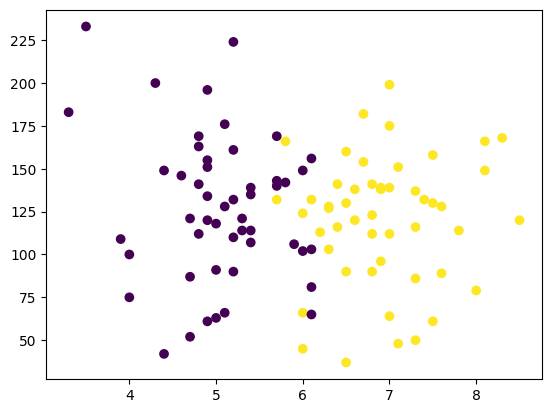

In [9]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [18]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [16]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [19]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [20]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [23]:
X_train

,cgpa,iq
80,4.9,196.0
43,6.8,141.0
87,5.7,132.0
25,5.0,91.0
48,6.6,138.0
...,...,...
35,6.8,90.0
22,4.9,120.0
52,7.0,175.0
71,6.1,132.0


In [24]:
X_test

,cgpa,iq
73,4.9,61.0
31,3.9,109.0
70,6.3,127.0
41,5.4,114.0
82,6.5,37.0
97,6.7,182.0
72,7.3,116.0
37,8.1,149.0
4,5.8,142.0
36,5.7,140.0


In [25]:
y_train

,placement
80,0
43,1
87,1
25,0
48,1
...,...
35,1
22,0
52,1
71,1


In [26]:
y_test

,placement
73,0
31,0
70,1
41,0
82,1
97,1
72,1
37,1
4,0
36,0


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler=StandardScaler()

In [29]:
X_train=scaler.fit_transform(X_train)

In [30]:
X_train


array([[-0.95248959,  1.81016365],
       [ 0.71803061,  0.422904  ],
       [-0.24911266,  0.19589788],
       [-0.86456747, -0.83824113],
       [ 0.54218638,  0.34723529],
       [ 1.15764119, -1.87238014],
       [ 0.89387485, -1.51925951],
       [-0.68872324, -0.35900598],
       [-1.04041171,  1.12914528],
       [-1.39210017, -2.07416336],
       [-1.04041171, -0.30856018],
       [-1.74378863, -1.24180758],
       [ 0.80595273,  0.3724582 ],
       [ 0.89387485,  1.88583236],
       [ 1.42140754, -0.88868694],
       [-0.07326843, -0.45989759],
       [-0.51287901,  0.3724582 ],
       [-1.39210017,  0.62468722],
       [-0.60080113, -0.25811437],
       [ 1.59725177, -0.25811437],
       [-1.21625594,  0.54901852],
       [-2.18339921,  2.74341105],
       [-0.51287901,  0.27156659],
       [ 0.27842003,  0.09500627],
       [ 0.45426427,  0.90213915],
       [ 0.01465369, -0.00588534],
       [ 2.21270659, -0.10677695],
       [ 0.98179696,  0.67513303],
       [ 0.54218638,

In [31]:
X_test=scaler.transform(X_test)

In [32]:
X_test

array([[-0.95248959, -1.59492821],
       [-1.83171075, -0.38422888],
       [ 0.27842003,  0.06978336],
       [-0.51287901, -0.25811437],
       [ 0.45426427, -2.20027788],
       [ 0.6301085 ,  1.45704301],
       [ 1.15764119, -0.20766857],
       [ 1.86101812,  0.62468722],
       [-0.16119055,  0.4481269 ],
       [-0.24911266,  0.3976811 ]])

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
clf=LogisticRegression()

In [35]:
clf.fit(X_train,y_train)

LogisticRegression()

In [38]:
y_pred=clf.predict(X_test)

In [37]:
y_test

,placement
73,0
31,0
70,1
41,0
82,1
97,1
72,1
37,1
4,0
36,0


In [39]:
from sklearn.metrics import accuracy_score

In [40]:
accuracy_score(y_test,y_pred)

1.0

In [41]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

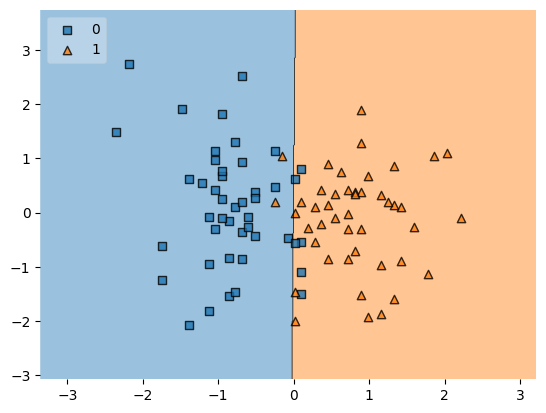

In [42]:
plot_decision_regions(X_train, y_train.values,
                                clf=clf, legend=2)

In [43]:
import pickle

In [44]:
pickle.dump(clf,open('model.pkl','wb'))